<h2>Apri questo notebook in Google Colab</h2>

<div align="left" style="margin: 20px 0;">
  <a href="https://colab.research.google.com/github/LeonardoCofone/The-AI-Handbook/blob/main/chapter_7_Machine_Learning.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
  </a>
</div>

# Capitolo 7, Regressione Polinomiale

In questo notebook vediamo come trasformare una semplice regressione lineare in un modello capace di seguire le curve.  
L'idea chiave: non cambiamo l'algoritmo, cambiamo le feature. Aggiungiamo potenze e radici, è la stessa vecchia regressione lineare impara curve complesse.

Lavoriamo su dati sintetici curvi, così puoi concentrarti sul concetto senza distrazioni. Cambia i parametri, rompi le cose, guarda cosa succede.

## 0. Setup, importare le librerie

In [1]:
%pip install numpy matplotlib scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import learning_curve

np.random.seed(42)
print('Setup completato!')

Setup completato!


## 1. Un problema che una retta non sa risolvere

Generiamo dei dati che seguono una curva cubica, con un po' di rumore.  
Sono dati finti, ma la forma "sale, rallenta, risale" è tipica di tantissimi fenomeni reali.

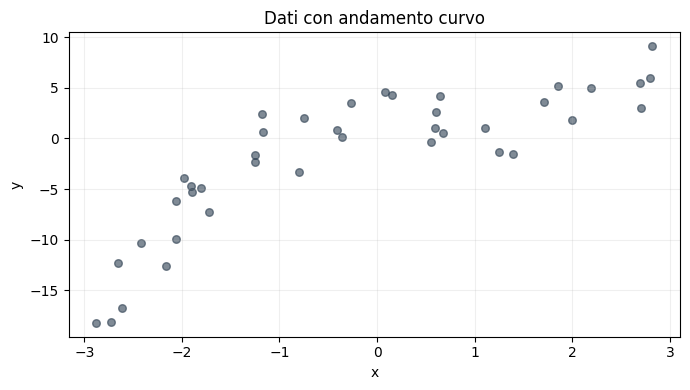

In [3]:
# Dati sintetici: relazione cubica con rumore
m = 40
X = np.sort(np.random.rand(m, 1) * 6 - 3, axis=0)   # x tra -3 e 3
y = 0.5 * X[:, 0]**3 - X[:, 0]**2 + 2 + np.random.randn(m) * 2.5

plt.figure(figsize=(7, 4))
plt.scatter(X, y, alpha=0.6, s=30, color='#2C3E50')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Dati con andamento curvo')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 2. Proviamo con una retta (e falliamo)

Alleniamo una regressione lineare normale. Vediamo subito che la retta non riesce a seguire la curva: è il classico **underfitting**.

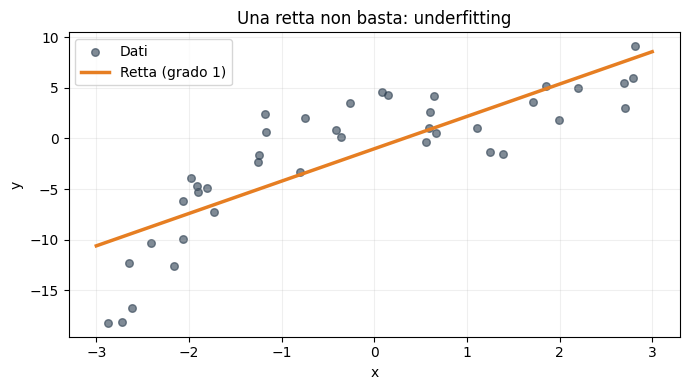

In [4]:
lin_reg = LinearRegression()
lin_reg.fit(X, y)

X_line = np.linspace(-3, 3, 300).reshape(-1, 1)
y_pred_lin = lin_reg.predict(X_line)

plt.figure(figsize=(7, 4))
plt.scatter(X, y, alpha=0.6, s=30, color='#2C3E50', label='Dati')
plt.plot(X_line, y_pred_lin, color='#E67E22', linewidth=2.5, label='Retta (grado 1)')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Una retta non basta: underfitting')
plt.legend(); plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 3. Il trucco: PolynomialFeatures

Invece di cambiare modello, arricchiamo le feature. `PolynomialFeatures(degree=2)` prende la colonna `x` e aggiunge `x^2`.  
Poi alleniamo la solita `LinearRegression` su queste feature trasformate. Guarda le prime righe prima e dopo la trasformazione.

In [5]:
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)

print('X originale (prime 3 righe):')
print(X[:3])
print()
print('X_poly con x e x^2 (prime 3 righe):')
print(X_poly[:3])

X originale (prime 3 righe):
[[-2.87649303]
 [-2.72129752]
 [-2.65149833]]

X_poly con x e x^2 (prime 3 righe):
[[-2.87649303  8.27421218]
 [-2.72129752  7.40546021]
 [-2.65149833  7.03044338]]


In [6]:
# Alleniamo la regressione lineare sulle feature polinomiali
lin_reg_poly = LinearRegression()
lin_reg_poly.fit(X_poly, y)

print('Pesi appresi (w1 per x, w2 per x^2):', lin_reg_poly.coef_.round(3))
print('Bias (b):', round(lin_reg_poly.intercept_, 3))

Pesi appresi (w1 per x, w2 per x^2): [ 3.123 -0.921]
Bias (b): 1.848


## 4. Il grado cambia tutto: underfitting vs overfitting

Proviamo tre gradi diversi sullo stesso dataset. Grado 1 sottostima, grado 3 azzecca la forma, grado 15 impazzisce seguendo il rumore.  
Questo è il compromesso bias-varianza del Capitolo 3, condensato in un solo iperparametro.

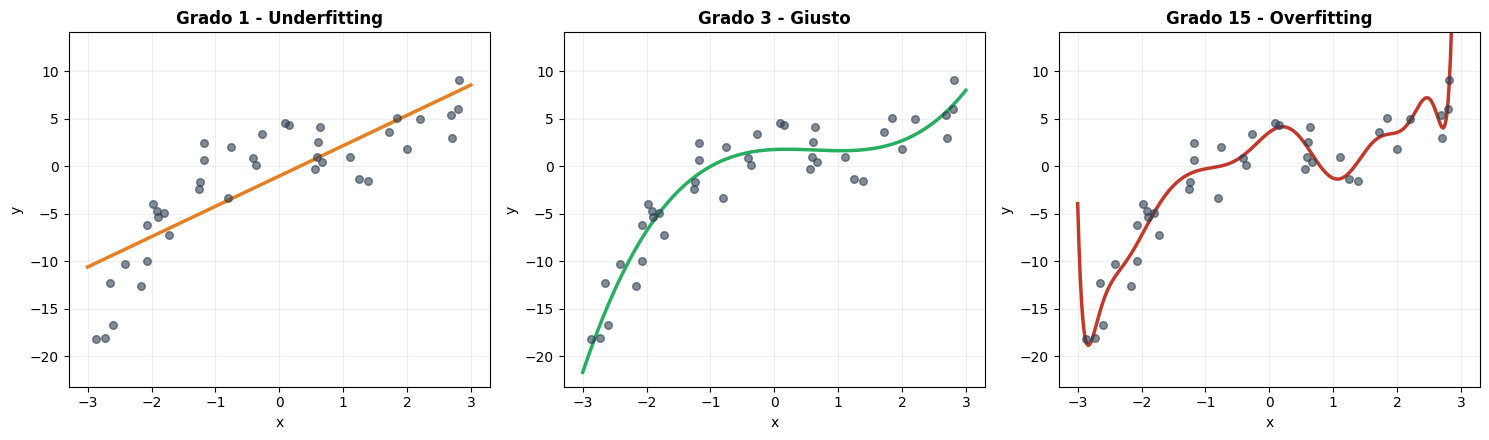

In [15]:
gradi = [1, 3, 15]
titoli = ['Grado 1 - Underfitting', 'Grado 3 - Giusto', 'Grado 15 - Overfitting']
colori = ['#E67E22', '#27AE60', '#C0392B']

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, grado, titolo, colore in zip(axes, gradi, titoli, colori):
    model = make_pipeline(PolynomialFeatures(degree=grado, include_bias=False), LinearRegression())
    model.fit(X, y)
    y_line = model.predict(X_line)
    ax.scatter(X, y, color='#2C3E50', s=30, alpha=0.6, zorder=3)
    ax.plot(X_line, y_line, color=colore, linewidth=2.5, zorder=2)
    ax.set_title(titolo, fontweight='bold')
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_ylim(y.min() - 5, y.max() + 5)
    ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 5. Non solo potenze: la trasformazione radice

Le potenze non sono l'unica strada. Quando i dati crescono in fretta e poi rallentano (rendimenti decrescenti), la radice quadrata li descrive meglio.  
Costruiamo la feature `sqrt(x)` a mano e la usiamo come input.

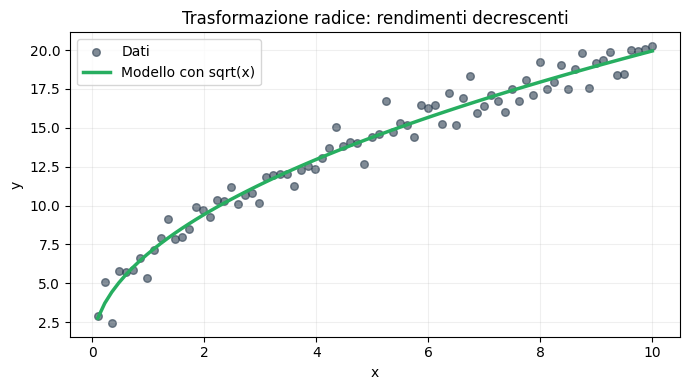

In [8]:
# Dati con andamento a rendimenti decrescenti
x_r = np.linspace(0.1, 10, 80).reshape(-1, 1)
y_r = 6 * np.sqrt(x_r[:, 0]) + 1 + np.random.randn(80) * 0.8

# Feature radice: affianchiamo x e sqrt(x)
X_sqrt = np.c_[x_r, np.sqrt(x_r)]

model_sqrt = LinearRegression()
model_sqrt.fit(X_sqrt, y_r)
y_pred_sqrt = model_sqrt.predict(X_sqrt)

plt.figure(figsize=(7, 4))
plt.scatter(x_r, y_r, alpha=0.6, s=30, color='#2C3E50', label='Dati')
plt.plot(x_r, y_pred_sqrt, color='#27AE60', linewidth=2.5, label='Modello con sqrt(x)')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Trasformazione radice: rendimenti decrescenti')
plt.legend(); plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 6. Con più feature: i termini di interazione

Con più di una feature, `PolynomialFeatures` non genera solo le potenze: crea anche i **prodotti** tra feature diverse (i termini di interazione).  
Vediamolo con due feature `a` e `b` a grado 2.

In [9]:
# Due feature di esempio
X_due = np.array([[2, 3],
                  [1, 5],
                  [4, 0]])

poly2 = PolynomialFeatures(degree=2, include_bias=False)
X_due_poly = poly2.fit_transform(X_due)

print('Nomi delle feature generate:')
print(poly2.get_feature_names_out())
print()
print('Valori trasformati:')
print(X_due_poly)

Nomi delle feature generate:
['x0' 'x1' 'x0^2' 'x0 x1' 'x1^2']

Valori trasformati:
[[ 2.  3.  4.  6.  9.]
 [ 1.  5.  1.  5. 25.]
 [ 4.  0. 16.  0.  0.]]


*Nota come compaia anche `x0 x1`, cioè il prodotto delle due feature: è il termine di interazione. Cattura l'idea che l'effetto di una feature dipenda dal valore dell'altra.*

## 7. Scegliere il grado con le learning curves

Il modo più chiaro per diagnosticare under/overfitting è guardare come si muovono errore di training e di validation al crescere dei dati.  
**Curve vicine e alte** = underfitting. **Divario ampio** = overfitting.

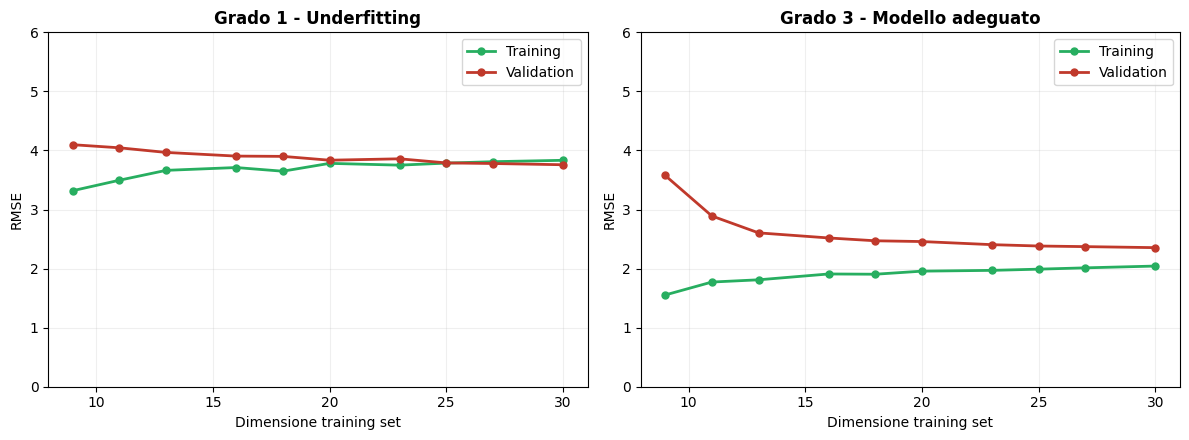

In [27]:
from sklearn.model_selection import ShuffleSplit

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
config = [(1, 'Grado 1 - Underfitting'), (3, 'Grado 3 - Modello adeguato')]

cv = ShuffleSplit(n_splits=20, test_size=0.25, random_state=42)

for ax, (grado, titolo) in zip(axes, config):
    model = make_pipeline(PolynomialFeatures(degree=grado, include_bias=False), LinearRegression())
    sizes, train_scores, val_scores = learning_curve(
        model, X, y, train_sizes=np.linspace(0.3, 1.0, 10), cv=cv,
        scoring='neg_root_mean_squared_error')
    train_rmse = -train_scores.mean(axis=1)
    val_rmse = -val_scores.mean(axis=1)
    ax.plot(sizes, train_rmse, 'o-', color='#27AE60', linewidth=2, markersize=5, label='Training')
    ax.plot(sizes, val_rmse, 'o-', color='#C0392B', linewidth=2, markersize=5, label='Validation')
    ax.set_title(titolo, fontweight='bold')
    ax.set_xlabel('Dimensione training set'); ax.set_ylabel('RMSE')
    ax.set_ylim(0, 6)
    ax.legend(); ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 8. Tocca a te: trova il grado migliore

Facciamo cross-validation su una griglia di gradi e troviamo quello con RMSE di validation più basso.  
Cambia il range dei gradi, il rumore dei dati, la dimensione del dataset: guarda come si sposta il grado ottimale.

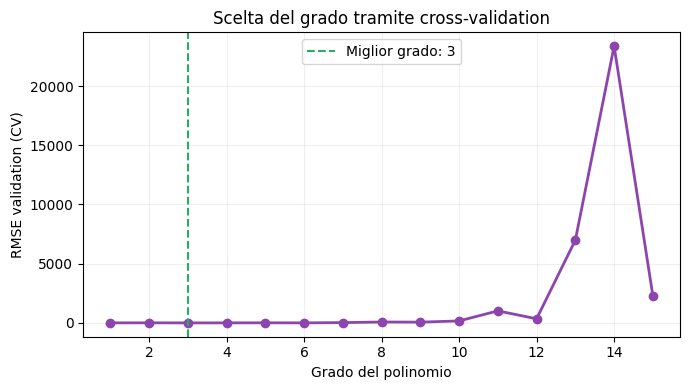

Il grado migliore secondo la cross-validation è: 3


In [12]:
from sklearn.model_selection import cross_val_score

gradi_test = range(1, 16)
rmse_medi = []

for g in gradi_test:
    model = make_pipeline(PolynomialFeatures(degree=g, include_bias=False), LinearRegression())
    scores = cross_val_score(model, X2, y2, cv=5, scoring='neg_root_mean_squared_error')
    rmse_medi.append(-scores.mean())

miglior_grado = list(gradi_test)[int(np.argmin(rmse_medi))]

plt.figure(figsize=(7, 4))
plt.plot(list(gradi_test), rmse_medi, 'o-', color='#8E44AD', linewidth=2)
plt.axvline(miglior_grado, color='#27AE60', linestyle='--', label=f'Miglior grado: {miglior_grado}')
plt.xlabel('Grado del polinomio'); plt.ylabel('RMSE validation (CV)')
plt.title('Scelta del grado tramite cross-validation')
plt.legend(); plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print(f'Il grado migliore secondo la cross-validation è: {miglior_grado}')

## In sintesi

Abbiamo visto che la regressione polinomiale non e un algoritmo nuovo: e la solita regressione lineare nutrita con feature trasformate (potenze, radici, interazioni).  
La struttura resta lineare nei parametri, cambia solo cosa diamo in pasto al modello.

Il grado e l'iperparametro critico: troppo basso porta a underfitting, troppo alto a overfitting. Si sceglie con cross-validation e learning curves, mai a occhio.

Nel prossimo capitolo vediamo come tenere a bada l'overfitting dei modelli flessibili con la **regolarizzazione**.